# Graficzne metryki oceny modeli klasyfikacyjnych

Ocena modeli klasyfikacyjnych za pomocą interpretacji graficznej to istotny etap analizy, który umożliwia nie tylko ilościową ocenę skuteczności predykcji (np. poprzez miary takie jak dokładność czy AUC), ale także zrozumienie zachowania modelu w różnych scenariuszach decyzyjnych. Wykresy te pomagają:

* dostrzec kompromis między błędami fałszywie pozytywnymi a fałszywie negatywnymi (np. ROC, Precision-Recall),
* ocenić jakość i równowagę klasyfikacji (Confusion Matrix),
* sprawdzić, czy prawdopodobieństwa przewidywane przez model są realistyczne (Calibration Curve),
* ocenić rozdzielczość między klasami (Histogram przewidywanych prawdopodobieństw).

Graficzna interpretacja pozwala lepiej zrozumieć mocne i słabe strony modelu oraz może wskazać konieczność jego poprawy, np. poprzez dostrojenie progu decyzyjnego, zastosowanie metod balansowania klas lub kalibrację predykcji. W praktyce stosowanie wielu wykresów jednocześnie daje najbardziej kompletny obraz działania modelu.

Najczęściej stosowane wykresy do oceny modeli klasyfikacyjnych:

* **ROC Curve (Receiver Operating Characteristic)**
  Pokazuje zależność między czułością (True Positive Rate) a odsetkiem fałszywych alarmów (False Positive Rate). Umożliwia obliczenie AUC jako miary ogólnej skuteczności klasyfikatora.

* **Precision-Recall Curve**
  Ilustruje zależność między precyzją a czułością. Szczególnie przydatna przy niezrównoważonych klasach, gdzie klasa pozytywna jest rzadka.

* **Confusion Matrix (Macierz pomyłek)**
  Pokazuje liczbę poprawnych i błędnych klasyfikacji dla każdej klasy. Jest podstawą do obliczania wielu metryk, np. accuracy, precision, recall, F1-score.

* **Histogram predicted probabilities**
  Przedstawia rozkład przewidywanych prawdopodobieństw dla każdej klasy. Ułatwia ocenę separacji między klasami i wskazuje na ewentualną potrzebę kalibracji.

* **Calibration Curve (Reliability Diagram)**
  Porównuje przewidywane prawdopodobieństwa z rzeczywistym udziałem klasy pozytywnej. Pomaga ocenić, czy model dobrze "wierzy" w swoje predykcje.

* **Lift Chart / Gain Chart**
  Pokazują, jak wiele więcej poprawnych klasyfikacji model identyfikuje w porównaniu z klasyfikacją losową. Popularne w zastosowaniach marketingowych.

* **Cumulative Accuracy Profile (CAP Curve)**
  Alternatywa dla wykresu ROC; pokazuje skumulowaną skuteczność modelu względem procentu próbek objętych klasyfikacją.

Przykłady wykresów

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, RocCurveDisplay,
    PrecisionRecallDisplay, brier_score_loss
)
from sklearn.calibration import CalibrationDisplay
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings

In [2]:
warnings.filterwarnings("ignore")

## Dane: German Credit Data.

<div style="text-align: center;"><img src=".//Images//Credit_data.jpeg" alt="Credit_data.jpeg" width="400" height="120" style="margin: 10px; "/></div>

Zbiór danych **German Credit** to klasyczny, rzeczywisty zbiór do zadań **klasyfikacji binarnej**. Jest szeroko wykorzystywany w testowaniu algorytmów uczenia maszynowego, zwłaszcza w kontekście **oceny ryzyka kredytowego**.

---

**Zadanie: ocena zdolności kredytowej klientów banku**

Celem modelu jest przewidzenie, czy klient będzie:

* **0 = good** – rzetelny kredytobiorca
* **1 = bad** – nierzetelny kredytobiorca (klasa pozytywna)

---

**Podstawowe informacje:**

* **Liczba próbek (obserwacji):** 1000
* **Liczba cech (atrybutów):** 20, cechy **numeryczne** (np. wiek, kwota kredytu), jak i **kategoryczne** (np. status konta, cel kredytu)
* **Zmienna docelowa:** `class` (good / bad)

---

**Charakterystyka cech:**

* Dane pochodzą z **instytucji finansowej** i zawierają:

  * dane demograficzne (wiek, płeć, stan cywilny),
  * historię kredytową (czas trwania, status konta),
  * dane o kredycie (kwota, cel, czas trwania),
  * dane dotyczące zabezpieczeń (np. właściciel mieszkania, telefon).

---

**Specyfika zbioru:**

* Dane są **niezrównoważone** — ok. **70% klientów** to przypadki klasy „good”.
* Zbiór wymaga często:

  * **przetworzenia cech kategorycznych** (np. one-hot encoding),
  * **standaryzacji cech liczbowych** (np. `age`, `credit_amount`),
  * uwzględnienia **ważenia klas** lub innych metod radzenia sobie z niezrównoważeniem.

---

**Zalety zastosowania:**

* Typowy przykład rzeczywistego zastosowania klasyfikacji (finanse).
* Idealny do testowania:

  * metryk klasyfikacyjnych (np. ROC, PR curve, AUC, F1),
  * kalibracji modeli,
  * analizy wpływu niezrównoważonych danych,
  * metod interpretacji modeli (SHAP, LIME).

---

**Źródło:**

* Zbiór pochodzi z **UCI Machine Learning Repository**
* Oryginalny opis: [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+%28german+credit+data%29)

---

UWAGA: Dla ułatwienia (i trochę pogorszenia wyników :) ) poniższe modele opierają się tylko na kolumnach numerycznych.

---

## Tworzenie modelu

**Wczytanie danych**:

In [3]:
from sklearn.datasets import fetch_openml

In [4]:
data = fetch_openml("credit-g", version=1, as_frame=True)
X = data.data.select_dtypes(include='number')  # tylko cechy liczbowe dla ułatwienia
y = data.target
class_names = y.unique().tolist()
print(class_names)
y = y.map({'good': 0, 'bad': 1}) # mapowanie ułatwiające dalsze analizy

['good', 'bad']


**Podział danych**:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

**Modele**:

In [6]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

**Generowanie raportu klasyfikacji**:

In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, digits=4, target_names=class_names))

              precision    recall  f1-score   support

        good     0.7377    0.9643    0.8359       140
         bad     0.7059    0.2000    0.3117        60

    accuracy                         0.7350       200
   macro avg     0.7218    0.5821    0.5738       200
weighted avg     0.7282    0.7350    0.6786       200



## ROC Curve - Receiver Operating Characteristic Curve

Wykres ROC służy do oceny jakości modelu klasyfikacyjnego, **szczególnie w klasyfikacji binarnej**. Pokazuje, jak model zachowuje się przy różnych progach decyzyjnych.

---

**Osie wykresu ROC**:

*Oś X* – **False Positive Rate (FPR)**

$$
\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
$$

Gdzie:

* **FP** – liczba fałszywie pozytywnych przypadków
* **TN** – liczba prawdziwie negatywnych przypadków

Warto zauważyć, że **specificity (True Negative Rate)** to:

$$
\text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}} = 1 - \text{FPR}
$$

* Specificity opisuje, jak dobrze model rozpoznaje **klasę negatywną**.
* Im wyższa **specificity**, tym niższy **FPR** – są swoim **lustrzanym odbiciem**.

*Oś Y* – **True Positive Rate (TPR), czyli czułość (Recall)**

$$
\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

Gdzie:

* **TP** – liczba prawdziwie pozytywnych przypadków
* **FN** – liczba fałszywie negatywnych przypadków

---

**Tworzenie krzywej ROC**:

Dla każdej wartości progu $t \in [0, 1]$:

1. Tworzona jest klasyfikacja: $y_{\text{pred}} = (y_{\text{proba}} \geq t)$
2. Obliczane są TPR i FPR
3. Punkt $(\text{FPR}(t), \text{TPR}(t))$ dodawany jest do wykresu

Z wielu takich punktów powstaje **ciągła krzywa ROC**.

---

**Interpretacja**:

* Punkt **(0,1)** oznacza idealny model: **0% fałszywie pozytywnych** i **100% prawdziwie pozytywnych**.
* Linia przekątna $(0,0) \rightarrow (1,1)$ reprezentuje **model losowy**.
* Im bliżej krzywej do lewego górnego rogu, tym lepszy model.

---

**AUC – Area Under Curve**:

* **AUC** to pole powierzchni pod krzywą ROC.
* Im wyższa wartość AUC, tym lepszy model.

Typowe wartości:

* **1.0** – klasyfikator idealny
* **0.5** – klasyfikator losowy
* **< 0.5** – klasyfikator gorszy niż losowy (np. zamienia klasy)

---

**Zalety wykresu ROC**:

* **Nie zależy od jednego progu** – pokazuje skuteczność dla wszystkich progów decyzyjnych.
* **Dobrze sprawdza się przy zrównoważonych klasach**. W przypadku silnie niezrównoważonych klas lepszym wyborem jest często **Precision-Recall Curve**.

---

In [8]:
from sklearn.metrics import roc_curve, auc

In [9]:
# Warto sprawdzić model i jego klasy, ROC domyślnie jest dla klasy = 1 jako pozytywnej
label_mapping = {i: name for i, name in zip(model.classes_, data.target_names)}
print(label_mapping)

{0: 'class'}


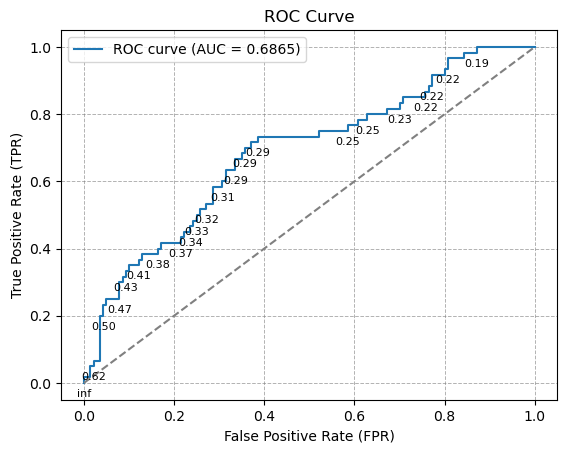

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.grid(color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.set_title("ROC Curve")
ax.legend()

# Dodanie wartości progów co n-ty punkt, UWAGA: standardowo progów się nie nanosi na krzywa ROC
step = max(1, len(thresholds) // 20)
for i in range(0, len(thresholds), step):
    ax.annotate(f"{thresholds[i]:.2f}", (fpr[i], tpr[i]), textcoords="offset points", xytext=(0, -10), ha='center', fontsize=8)

plt.show()

**Interpretacja krzywej ROC** 

* **AUC = 0.6865** oznacza, że model ma umiarkowaną zdolność rozróżniania między klasą pozytywną a negatywną. 68% szans, że model przypisze inną wartość predykcji losowo wybranemu przypadkowi pozytywnemu niż losowo wybranemu przypadkowi negatywnemu.

* Krzywa ROC pokazuje **typowy kompromis**: wyższy TPR = wyższy FPR.
* **Dla progów 0.3–0.5** model osiąga już znaczącą czułość (`TPR ≈ 0.5–0.6`), ale z umiarkowanym FPR (`0.25–0.3`).
* Najlepsze progi zależą od priorytetu:

  * Jeśli ważniejsze jest **uniknięcie błędów fałszywie pozytywnych** → wybierz **wyższy próg** (mniejszy FPR, kosztem TPR).
  * Jeśli ważniejsze jest **wykrycie wszystkich pozytywnych** → wybierz **niższy próg** (większy TPR, kosztem FPR).

---

**Przykład decyzyjny**:

| Threshold | TPR (Recall) | FPR    | Uwagi                                                   |
| --------- | ------------ | ------ | ------------------------------------------------------- |
| 0.5036    | 0.20         | 0.0357 | Mało wykryć, niski fałszywy alarm                       |
| 0.3079    | 0.5833       | 0.2857 | Dobry kompromis                                         |
| 0.2240    | 0.8833       | 0.7643 | Wysoka czułość, ale wiele błędów                        |
| 0.1062    | 1.00         | 1.00   | Wszystko zakwalifikowane jako pozytywne (niepraktyczne) |

---

In [11]:
df_roc = pd.DataFrame({
    "threshold": thresholds,
    "fpr": fpr,
    "tpr": tpr
})
df_roc = df_roc.round(4)
path_roc = "./Results/roc.csv"
df_roc.to_csv(path_roc, index=False)

Poniżej znajduje się kod, który umożliwia dodanie dowolnej liczby modeli klasyfikacyjnych do listy słownikowej i automatyczne wygenerowanie wykresu ROC z porównaniem ich skuteczności (AUC):

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

## PR Curve - Precision-Recall Curve

Wykres Precision-Recall (PR) służy do oceny jakości modelu klasyfikacyjnego, **szczególnie przy niezrównoważonych zbiorach danych**. Pokazuje, jak model radzi sobie z wykrywaniem klasy pozytywnej przy różnych progach decyzyjnych.

---

**Osie wykresu PR**:

*Oś X* – **Recall (TPR, czułość)**

$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

Gdzie:

* **TP** – liczba prawdziwie pozytywnych przypadków
* **FN** – liczba fałszywie negatywnych przypadków

Opisuje, jaki **odsetek rzeczywistych przykładów pozytywnych został poprawnie wykryty** przez model.

*Oś Y* – **Precision (precyzja)**

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

Gdzie:

* **TP** – liczba prawdziwie pozytywnych przypadków
* **FP** – liczba fałszywie pozytywnych przypadków

Opisuje, **jaki odsetek zaklasyfikowanych jako pozytywne** rzeczywiście był pozytywny.

---

**Tworzenie krzywej PR**:

Dla każdej wartości progu $t \in [0, 1]$:

1. Tworzona jest klasyfikacja: $y_{\text{pred}} = (y_{\text{proba}} \geq t)$
2. Obliczane są wartości Precision i Recall
3. Punkt $(\text{Recall}(t), \text{Precision}(t))$ dodawany jest do wykresu

Z tych punktów powstaje **krzywa Precision-Recall**, której kształt zależy od proporcji klas i skuteczności modelu.

---

**Interpretacja**:

* Im większa **precyzja przy danym recall**, tym lepszy model.
* Idealny model: punkt **(1, 1)** – 100% trafień, 0% fałszywych alarmów.
* W przeciwieństwie do ROC, tutaj nawet dobra wartość recall może być bezwartościowa, jeśli precision jest niska (i odwrotnie).
* Linia bazowa to wartość **prevalence** (udział klasy pozytywnej) — model losowy osiąga precision równą częstości klasy pozytywnej.

---

**AUC dla PR – Average Precision (AP)**:

Miara **AUC w kontekście PR** nazywa się **Average Precision** (AP). Jest to uśredniona precyzja ważona przyrostami recall:

$$
\text{AP} = \sum_n (\text{Recall}_n - \text{Recall}_{n-1}) \cdot \text{Precision}_n
$$

AP można traktować jako pole powierzchni pod wykresem PR. Im wyższe AP, tym lepszy model.

---

**Zalety wykresu Precision-Recall**:

* **Lepiej niż ROC** pokazuje działanie modelu przy **silnie niezrównoważonych klasach**.
* Bardziej rygorystyczny niż ROC — ukazuje skuteczność tylko w odniesieniu do **klasy pozytywnej**, bez „maskowania” wynikami klasy negatywnej.
* Ujawnia kompromis: **więcej trafień (recall) może oznaczać mniej trafnych wyników (precision)**.

---

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

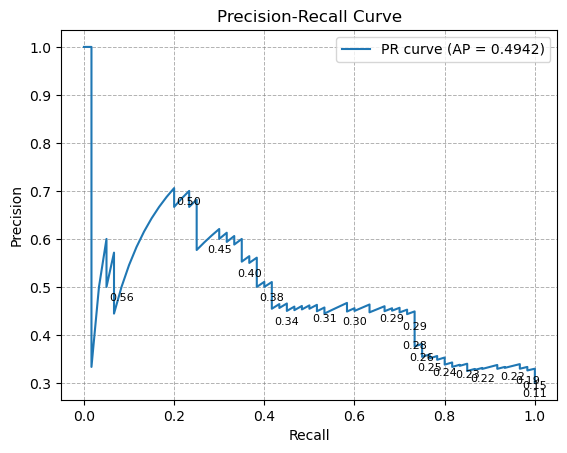

In [14]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots()
ax.plot(recall, precision, label=f"PR curve (AP = {ap:.4f})")
ax.grid(color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

# Dodanie wartości progów co n-ty punkt (jeden mniej niż precision/recall)
step = max(1, len(thresholds) // 20)
for i in range(0, len(thresholds), step):
    ax.annotate(f"{thresholds[i]:.2f}", (recall[i], precision[i]), textcoords="offset points", xytext=(0, -10), ha='center', fontsize=8)

plt.show()

**Interpretacja**:
  
* Wartość **AP = 0.4942** (Average Precision) oznacza, że model osiąga **średnią precyzję 49,42%** przy wykrywaniu klasy pozytywnej w całym zakresie progów decyzyjnych.
* **PR curve pokazuje silny kompromis między precision a recall** – im większa czułość, tym mniejsza precyzja.
* Przy niezrównoważonych klasach ta krzywa lepiej pokazuje **skuteczność wykrywania klasy mniejszościowej** niż ROC.
* Model ma użyteczne zakresy działania przy progach **0.2–0.3**, gdzie precision \~0.4–0.5, a recall \~0.7–0.9.

---

**Wnioski**:

* Jeśli zależy Ci na **maksymalnym wykrywaniu pozytywnych (recall)**, możesz używać niskiego progu (\~0.15–0.20), akceptując niski precision.
* Jeśli ważniejsza jest **pewność wykryć (precision)**, stosuj próg \~0.35–0.45, gdzie precision rośnie do \~0.6 kosztem recall spadającego do \~0.3.
* **Najlepszy próg decyzyjny** zależy od kosztu błędu fałszywie pozytywnego vs fałszywie negatywnego.

---

In [15]:
df_pr = pd.DataFrame({
    "threshold": [None] + list(thresholds),  # dopasowanie do długości, bo 1 próg = inf
    "precision": precision,
    "recall": recall
})
df_pr = df_pr.round(4)
path_pr = "./Results/precision_recall.csv"
df_pr.to_csv(path_pr, index=False)

## DET Curve – Detection Error Tradeoff Curve

**DET Curve** służy do oceny klasyfikatora binarnego, podobnie jak krzywa ROC, ale prezentuje dane w sposób, który **bardziej uwidacznia różnice w jakości klasyfikacji**, zwłaszcza przy niskich poziomach błędów.

---

**Osie wykresu DET**:

* **Oś X** – *False Positive Rate (FPR)*
* **Oś Y** – *False Negative Rate (FNR)*

- Obie osie są zwykle przekształcone przez odwrotną funkcję dystrybuanty normalnej (tzw. **probit scale**).
- Skala jest **nieliniowa** i wyraźniej rozciąga wartości w zakresie niskich błędów.

---

**Definicje**:

* **FPR (False Positive Rate)** – odsetek przypadków negatywnych błędnie zakwalifikowanych jako pozytywne:

  $$  \text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}  $$

* **FNR (False Negative Rate)** – odsetek przypadków pozytywnych błędnie zakwalifikowanych jako negatywne:

  $$  \text{FNR} = \frac{\text{FN}}{\text{FN} + \text{TP}} = 1 - \text{Recall}  $$

---

**Tworzenie krzywej DET:**

1. Oblicz FPR i FNR dla wielu progów decyzyjnych.
2. Przekształć wartości FPR i FNR funkcją probit (odwrotna dystrybuanta normalna).
3. Wykreśl FNR względem FPR.

---

**Interpretacja**:

* **Lewy dolny róg** wykresu (FPR ≈ 0, FNR ≈ 0) to model idealny.
* Im bliżej krzywa znajduje się **tego rogu**, tym lepszy model.
* Krzywa **bliższa przekątnej** (FPR = FNR) oznacza model losowy.
* Krzywa **niższa i bardziej zakrzywiona** sugeruje lepszą zdolność rozróżniania klas.

---

**Miara jakości: Equal Error Rate (EER)**

* Punkt przecięcia: **FPR = FNR**

* Wartość EER jest **jedną liczbą charakteryzującą model**:

  $$  \text{EER} = \text{FPR} = \text{FNR} \text{ w punkcie przecięcia}  $$

* Im niższe EER, tym lepszy model.

---

**Zastosowania**:

DET Curve jest preferowana w dziedzinach, gdzie **niskie poziomy błędów są kluczowe**, np.:

* rozpoznawanie mowy,
* biometryka (odcisk palca, twarz, głos),
* systemy bezpieczeństwa,
* systemy detekcji oszustw.

---

**Zalety DET Curve**:

* Lepsze uwidocznienie różnic jakości klasyfikatorów przy **małych wartościach FPR/FNR** niż ROC.
* Umożliwia ocenę działania modeli w rygorystycznych warunkach (np. tolerancja tylko 1% błędów).
* Ułatwia porównanie modeli, które w ROC wyglądają podobnie.

---

In [16]:
from sklearn.metrics import DetCurveDisplay

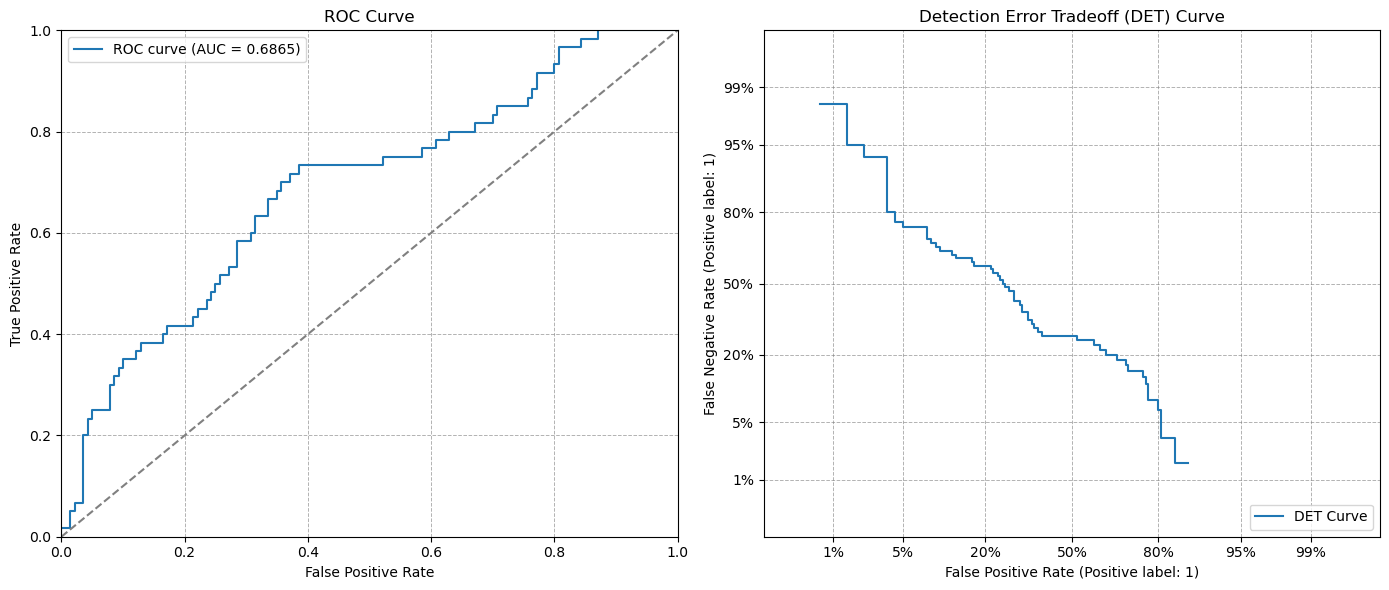

In [17]:
# Krzywa ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.grid(color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend()

# DET Curve
DetCurveDisplay.from_predictions(y_test, y_proba, ax=ax2, label="DET Curve")
ax2.set_title("Detection Error Tradeoff (DET) Curve")
ax2.grid(color="gray", linestyle="--", linewidth=0.7, alpha=0.6)

plt.tight_layout()
plt.show()

Porównanie dwóch wykresów:

---

**ROC Curve (po lewej)**:

* Pokazuje relację między **True Positive Rate (TPR)** a **False Positive Rate (FPR)**.
* Im bliżej lewego górnego rogu, tym lepszy model.
* AUC = 0.68 oznacza umiarkowaną zdolność rozróżniania klas.

---

**DET Curve (po prawej)**:

* Pokazuje kompromis między **False Negative Rate (FNR)** a **False Positive Rate (FPR)**.
* Lepsze modele mają DET krzywą **bliżej lewego dolnego rogu**.
* DET jest bardziej czuła na zmiany jakości, szczególnie przy niskich poziomach błędów.

https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_display_object_visualization.html#sphx-glr-auto-examples-miscellaneous-plot-display-object-visualization-py

## Confusion Matrix (Macierz Pomyłek)

Macierz pomyłek to podstawowe narzędzie do oceny skuteczności klasyfikatora binarnego. Przedstawia **liczebność przypadków** dla czterech możliwych wyników klasyfikacji.

---

**Struktura macierzy (dla klasyfikacji binarnej)**:

|                              | **Rzeczywista klasa: Pozytywna (1)** | **Rzeczywista klasa: Negatywna (0)** |
| ---------------------------- | ------------------------------------ | ------------------------------------ |
| **Predykcja: Pozytywna (1)** | TP – True Positives                  | FP – False Positives                 |
| **Predykcja: Negatywna (0)** | FN – False Negatives                 | TN – True Negatives                  |

---

**Definicje elementów**:

* **TP (True Positives)** – prawdziwie pozytywne: model poprawnie przewidział klasę pozytywną.
* **FP (False Positives)** – fałszywie pozytywne: model błędnie przypisał klasę pozytywną (tzw. *false alarm*).
* **TN (True Negatives)** – prawdziwie negatywne: model poprawnie przewidział klasę negatywną.
* **FN (False Negatives)** – fałszywie negatywne: model błędnie zakwalifikował przypadek pozytywny jako negatywny.

---

**Metryki wyliczane z macierzy**:

* **Accuracy**: ogólna trafność

  $$  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}  $$

* **Precision** (Precyzja):

  $$  \text{Precision} = \frac{TP}{TP + FP}  $$

* **Recall (Sensitivity / TPR)**:

  $$  \text{Recall} = \frac{TP}{TP + FN}  $$

* **Specificity (TNR)**:

  $$  \text{Specificity} = \frac{TN}{TN + FP}  $$

* **F1-score** (harmoniczna średnia Precision i Recall):

  $$  \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}  $$

---

**Interpretacja i zastosowanie**:

* **CM uwzględnia konkretny próg decyzyjny** — w przeciwieństwie do ROC/PR, które pokazują działanie modelu dla wszystkich progów.
* Pozwala zobaczyć **strukturę błędów**: np. czy model częściej myli pozytywne z negatywnymi, czy odwrotnie.
* Idealna macierz ma **0** w komórkach FP i FN.

---

**Zalety**:

* Jasne pokazanie, **gdzie model się myli**.
* Konieczne przy ocenie kosztów błędów: np. FN może być gorszy niż FP (np. w diagnozie medycznej).

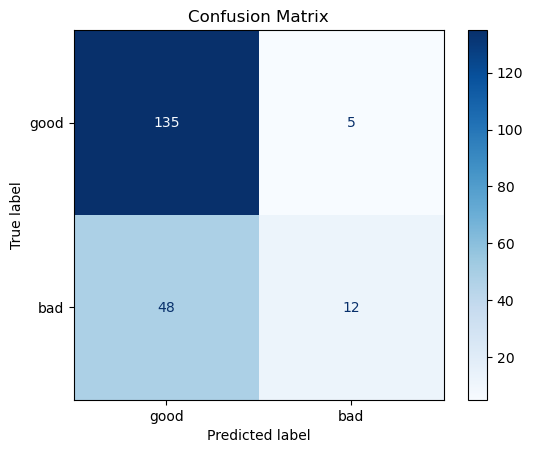

In [18]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix")

plt.show()

## Histogram predicted probabilities

Wykres histogramu prawdopodobieństw predykcji przedstawia rozkład **prawdopodobieństw klasy pozytywnej**, jakie model przypisał wszystkim przykładom testowym. To jedno z najprostszych, ale **bardzo informacyjnych narzędzi diagnostycznych**.

---

**Oś X** – *Prawdopodobieństwo klasy pozytywnej (`y_proba`)*

$$ y_{\text{proba}} = \text{model.predict\_proba}(X)[:, 1] $$

* Zakres od `0.0` (pewność klasy negatywnej) do `1.0` (pewność klasy pozytywnej).
* Oś X pokazuje **poziom pewności modelu**.

---

**Oś Y** – *Liczba przykładów*

* Pokazuje, **ilu przykładom** model przypisał daną wartość prawdopodobieństwa.
* Często wykres dzieli się na dwie osobne grupy:

  * klasy pozytywne (`y = 1`)
  * klasy negatywne (`y = 0`)

---

**Interpretacja**:

* **Dobry model**:

  * **dla klasy 0**: prawdopodobieństwa bliskie 0
  * **dla klasy 1**: prawdopodobieństwa bliskie 1
  * Histogramy są wyraźnie **oddzielone**

* **Zły model**:

  * Wszystkie prawdopodobieństwa skoncentrowane w okolicy 0.5 – brak rozróżnialności.
  * Histogramy obu klas mocno **nakładają się na siebie**.

---

**Zastosowanie**:

* **Zrozumienie, jak "pewny" jest model** w swoich predykcjach.
* Ułatwia **dobór progu decyzyjnego** (np. `0.3`, `0.6` zamiast domyślnego `0.5`).
* Może ujawnić **kalibracyjne problemy** — np. model przypisuje zbyt wysokie lub zbyt niskie prawdopodobieństwa.

---

**Uwaga**:

* Histogram nie pokazuje wyników klasyfikacji, tylko **ciągłe predykcje** (`predict_proba`).
* Dobrym uzupełnieniem histogramu jest **krzywa kalibracyjna** (calibration curve).

---

In [19]:
import seaborn as sns

In [20]:
plt.style.use("seaborn-v0_8-whitegrid")

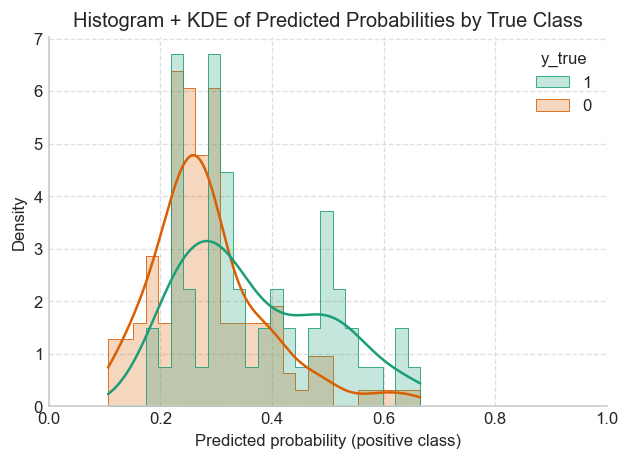

In [21]:
# Dane do histogramu
df_probs = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba
})

plt.figure(figsize=(6, 4), dpi=120)
sns.histplot(data=df_probs, x="y_proba", hue="y_true", bins=25, stat="density", common_norm=False,
             element="step", kde=True, palette="Dark2", linewidth=0.5)
plt.xlabel("Predicted probability (positive class)")
plt.ylabel("Density")
plt.title("Histogram + KDE of Predicted Probabilities by True Class")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(0, 1)
sns.despine()                    # usuwa górną i prawą ramkę
plt.show()

**Interpretacja**:

Powyższy wykres przedstawia **rozkład przewidywanych prawdopodobieństw** dla klasy pozytywnej, z podziałem na faktyczną klasę (`y_true`):

* **Kolory** odpowiadają klasom rzeczywistym: `0` (good) i `1` (bad).
* **Lepszy model** daje:

  * wartości bliskie 0 dla klasy `0` (negatywnej),
  * wartości bliskie 1 dla klasy `1` (pozytywnej),
  * niewiele wartości wokół 0.5.

Obecnie histogram pokazuje częściowe rozdzielenie, ale też **duże nakładanie**, co oznacza umiarkowaną jakość klasyfikatora.

Na wykresie dodano krzywe **gęstości KDE** (kernel density estimate) dla każdej klasy:

* Uzupełniają histogram, pokazując bardziej płynny kształt rozkładu prawdopodobieństw.
* Ułatwiają identyfikację, gdzie **najczęściej znajdują się predykcje** dla każdej klasy.
* Duże **nakładanie się krzywych** oznacza, że model ma trudność z jednoznacznym rozróżnieniem klas.

## Calibration Curve (Krzywa Kalibracji)

Wykres kalibracji służy do oceny **zgodności między przewidywanymi prawdopodobieństwami a rzeczywistymi częstościami zdarzeń**. To kluczowe narzędzie, gdy model zwraca nie tylko klasy, ale **prawdopodobieństwa** — szczególnie ważne w zastosowaniach decyzyjnych (np. medycyna, finanse, ubezpieczenia).

---

**Osie wykresu Calibration Curve**

* **Oś X** – *przewidywane prawdopodobieństwo*
  Przeciętna wartość `y_proba` w danym przedziale (np. 0.1–0.2, 0.2–0.3, ...)

* **Oś Y** – *rzeczywista częstość pozytywnych przypadków*
  Odsetek przykładów z `y_true = 1` w danym przedziale prawdopodobieństwa

---

**Jak powstaje krzywa kalibracji**:

1. Przypadki są **dzielone na przedziały** według przewidywanego `y_proba` (np. 10 równych przedziałów).
2. W każdym przedziale obliczana jest:

   * **średnia wartość `y_proba`** (X),
   * **częstość rzeczywistych klas pozytywnych** (Y).
     
3. Wykreślamy punkty **(X, Y)** i łączymy linią.

---

**Idealna kalibracja**:

* Linia **y = x** oznacza model idealnie skalibrowany:
  np. jeśli model przypisuje 0.7, to rzeczywiście 70% takich przypadków należy do klasy pozytywnej.

---

**Interpretacja**:

* **Krzywa nad przekątną**: model **zaniża prawdopodobieństwa** – jest **optymistyczny**.
* **Krzywa pod przekątną**: model **zawyża prawdopodobieństwa** – jest **pesymistyczny**.
* **Duże odchylenie od przekątnej** oznacza, że model **nie powinien być używany do decyzji probabilistycznych** (np. ranking, scoring, ocena ryzyka).

---

**Zastosowanie**:

* Kiedy ważne jest nie tylko *kto wygra*, ale *z jakim prawdopodobieństwem*.
* Przydatny do:

  * oceny systemów scoringowych,
  * określenia sensownych progów decyzyjnych,
  * **kalibracji modelu**: np. `CalibratedClassifierCV`, `Platt Scaling`, `Isotonic Regression`.

---

**Wskazówki praktyczne**:

* Histogram (barplot) często dodaje się poniżej krzywej – pokazuje **ile przypadków** model klasyfikował w każdym przedziale.
* Modele typu **Random Forest** lub **XGBoost** często są **źle skalibrowane**, mimo dobrej jakości klasyfikacji (np. wysokie AUC).
* Model może być świetny na ROC Curve, a nadal źle skalibrowany — **to różne aspekty oceny**.

---

https://scikit-learn.org/stable/auto_examples/calibration/plot_compare_calibration.html#sphx-glr-auto-examples-calibration-plot-compare-calibration-py

In [22]:
from sklearn.calibration import calibration_curve

In [23]:
# Ustaw styl uproszczony i cienkie linie
plt.style.use("default")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 120

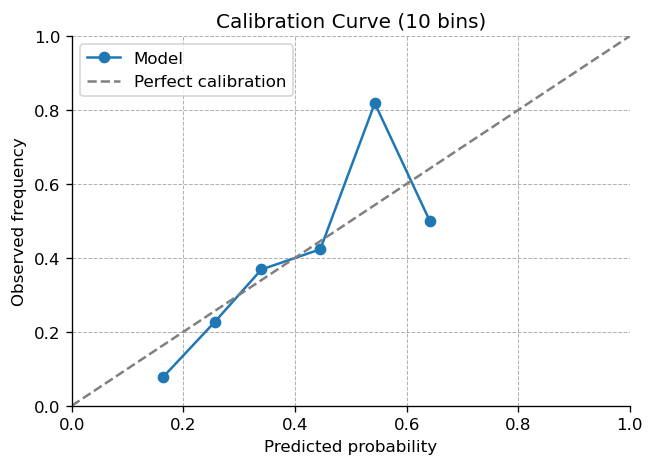

In [24]:
# Obliczenie krzywej kalibracyjnej
n_bins = 10
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=n_bins, strategy='uniform')

# Wykres
plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.grid(color="gray", linestyle="--", linewidth=0.6, alpha=0.6)
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title(f"Calibration Curve ({n_bins} bins)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

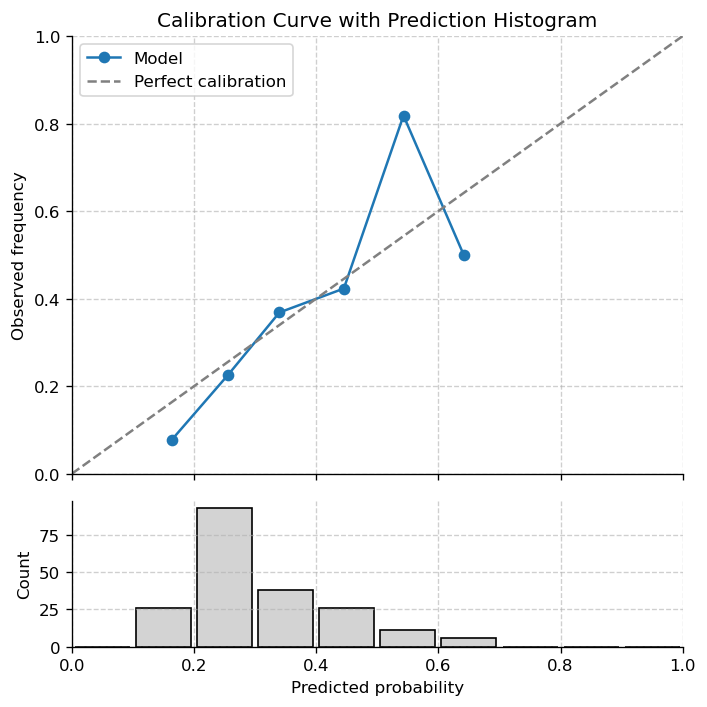

In [25]:
# Dodatkowo z histogramem
n_bins = 10
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=n_bins, strategy='uniform')

# Obliczenie liczności w przedziałach
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_counts, _ = np.histogram(y_proba, bins=bin_edges)

# Wykres z krzywą kalibracyjną i histogramem
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Krzywa kalibracyjna
ax1.plot(prob_pred, prob_true, marker='o', label="Model")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax1.set_ylabel("Observed frequency")
ax1.set_title("Calibration Curve with Prediction Histogram")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Histogram predykcji
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
ax2.bar(bin_centers, bin_counts, width=0.09, align='center', color='lightgray', edgecolor='black')
ax2.set_xlabel("Predicted probability")
ax2.set_ylabel("Count")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

**Interpretacja**:

Wykres kalibracyjny jest przedstawiony z histogramem częstości predykcji (liczba przypadków w przedziałach prawdopodobieństw):
* **Górny wykres**: klasyczna krzywa kalibracyjna pokazująca zgodność między y_proba a faktyczną częstością klasy pozytywnej.
* **Dolny wykres**: liczba próbek w każdym z 10 przedziałów — pokazuje, gdzie model „koncentruje” swoje przewidywania.

To połączenie ułatwia ocenę zarówno jakości kalibracji, jak i rozłożenia zaufania modelu.

---

**Opis fragmentów**:

| Śr. przewidywane (`y_proba`) | Rzeczywista częstość (`y_true = 1`) | Interpretacja                          |
| ---------------------------- | ----------------------------------- | -------------------------------------- |
| 0.1632                       | 0.0769                              | model **zawyża** prawdopodobieństwa    |
| 0.2557                       | 0.2258                              | model **lekko zawyża**                 |
| 0.3397                       | 0.3684                              | model **lekko zaniża**                 |
| 0.4452                       | 0.4231                              | prawie **dobrze skalibrowany**         |
| 0.5429                       | 0.8182                              | model **mocno zaniża** — zbyt ostrożny |
| 0.6414                       | 0.5                                 | model **zawyża** — zbyt pewny          |

---

**Wnioski ogólne:**

* **Pierwszy przedział**: model przypisuje \~16% szansy na klasę pozytywną, ale rzeczywista częstość to tylko 7.7% – **przeszacowanie (zawyżenie)**.
* **Środkowe przedziały** (ok. 0.25–0.45): model zbliża się do idealnej kalibracji.
* **Przedział \~0.54**: model **mocno zaniża** — przypisuje 54%, a faktycznie pozytywnych było ponad 81%.
* **Przedział \~0.64**: znów **zawyżenie** – model przewiduje wyższe prawdopodobieństwo niż rzeczywistość.

---

**Podsumowanie**:

* Kalibracja jest **nieliniowa** – w niskich progach model jest zbyt pewny, w średnich działa dobrze, a w wyższych bywa nadmiernie ostrożny **lub** nadmiernie optymistyczny.

In [26]:
df_calibration = pd.DataFrame({
    "predicted_probability": prob_pred,
    "observed_frequency": prob_true
})

# Zaokrąglenie do 4 miejsc po przecinku
df_calibration = df_calibration.round(4)

# Zapis do pliku CSV
csv_path = "./Results/calibration_curve.csv"
df_calibration.to_csv(csv_path, index=False)